In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('dataset.csv')

In [3]:
print(df.shape)
print(df.columns.tolist())
print(df.head(3))
print(df.shape)        
print(df.dtypes)
print(df.isnull().sum())
print((df.isnull().sum() / len(df) * 100).round(1))
print(df.describe())

(1460, 81)
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea

In [48]:
df.replace('?', np.nan, inplace=True)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,...,112,0,0,0,0,4,2010,WD,Normal,142125


In [62]:
cols = ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')


In [63]:
df = df.loc[:, df.isnull().mean() < 0.4]

In [60]:
for col in df.columns:
    if df[col].isnull().any():
        if pd.api.types.is_numeric_dtype(df[col]):
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
        else:
            mode_val = df[col].mode()[0]
            df[col] = df[col].fillna(mode_val)


In [68]:
df.to_csv('cleaned_dataset.csv', index=False)
print("Data cleaning complete. Saved to 'cleaned_dataset.csv'.")

Data cleaning complete. Saved to 'cleaned_dataset.csv'.


In [50]:
X = df[['LotArea', 'OverallQual', 'YearBuilt', 'GrLivArea', 'GarageCars']]
y = df['SalePrice']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [53]:
y_pred = model.predict(X_test)
y_pred

array([139058.03142021, 291913.79289788, 116292.34168029, 175037.94295727,
       286858.35627832,  53795.76991271, 217773.84544389, 174510.86777708,
        53386.47290413, 135322.86946001, 167106.23831149, 109549.72757444,
        89463.38157129, 217680.23995831, 199020.70224233, 109644.17961812,
       225219.60884148, 116967.6767875 , 119751.03131117, 214944.45762785,
       169115.36635317, 244026.45493428, 190886.34909958, 104818.94128065,
       209744.19186398, 172114.95326168, 208242.97980457, 102492.86354724,
       195870.18873063, 204721.81041945, 118805.23352952, 258311.80741406,
       200628.98130167,  84632.33317468, 264689.46995812, 143786.88831571,
       151088.04280136, 235008.66769094, 303927.5500068 , 107625.42342981,
       147112.18992785, 241041.62184706, 114346.05384891, 284739.99527848,
       128113.8959103 , 164551.73696211, 108242.10619044, 111070.37609107,
       343927.91948359, 138808.47757956, 106140.27506788, 185594.41425799,
       127965.13022551, 3

In [54]:
r2_score(y_test, y_pred)

0.7712417208024229

In [55]:
mae = mean_absolute_error(y_test, y_pred)
mae

26841.400136401615

In [56]:
mse = mean_squared_error(y_test,y_pred)
mse


1754650624.0402048

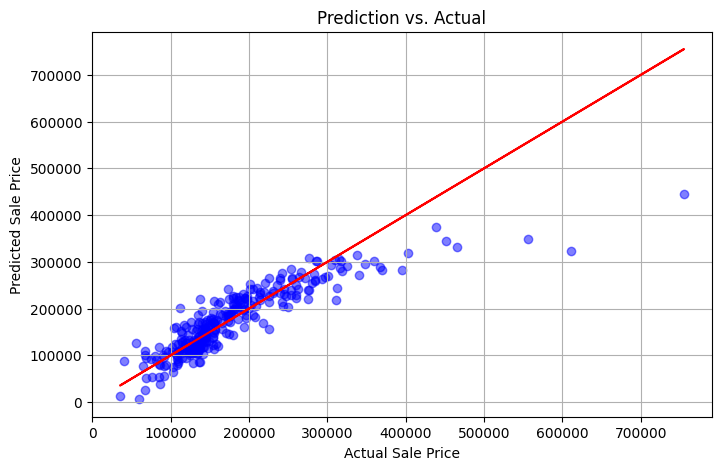

In [64]:
# Prediction vs. Actual Plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot(y_test, y_test, color="red")  
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.grid()
plt.title('Prediction vs. Actual')
plt.savefig('prediction_vs_actual.png')

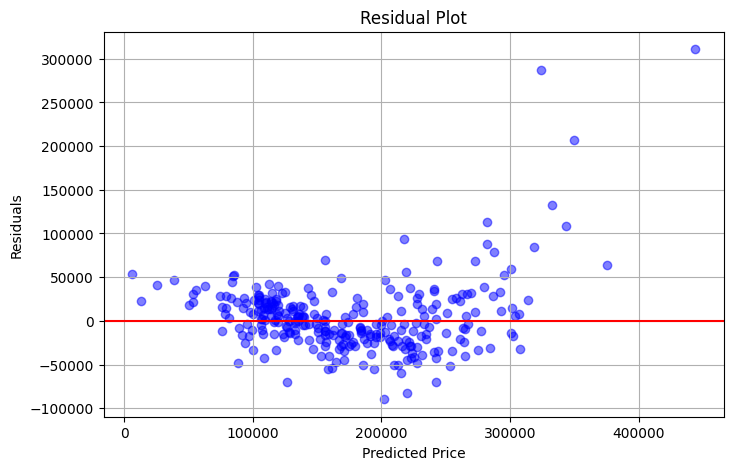

In [67]:
# Residual Plot
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, y_test - y_pred, alpha=0.5, color='blue')
plt.axhline(0, color='red') 
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.grid()
plt.title('Residual Plot')
plt.savefig('residual_plot.png')

Plots saved successfully.


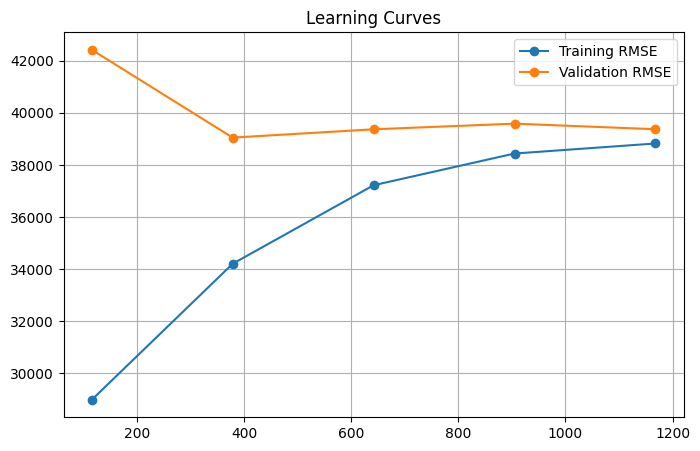

In [66]:
# Learning Curves
train_sizes, train_scores, test_scores = learning_curve(
    LinearRegression(), X, y, cv=5, scoring='neg_mean_squared_error'
)
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, np.sqrt(-train_scores.mean(axis=1)), 'o-', label='Training RMSE')
plt.plot(train_sizes, np.sqrt(-test_scores.mean(axis=1)), 'o-', label='Validation RMSE')
plt.title('Learning Curves')
plt.grid()
plt.legend()
plt.savefig('learning_curves.png')

print("Plots saved successfully.")